In [1]:
import os
import sys
sys.path.append("/pscratch/sd/l/lindajin/DH_profile_kSZ_WL")
from src.models.flow_nn import *
from src.data.camels_dataloader import get_train_val_test_dataloaders
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import argparse

from lightning.pytorch import seed_everything, Trainer
from lightning.pytorch.loggers import WandbLogger, TensorBoardLogger
from lightning.pytorch.callbacks import ModelCheckpoint, LearningRateMonitor

data_dir = "/pscratch/sd/l/lindajin/DH_profile_kSZ_WL/data"

train_dataloader, val_dataloader, test_dataloader = get_train_val_test_dataloaders(
        data_dir, 
        batch_size=32,
        train_ratio=0.7,
        val_ratio=0.15,
        test_ratio=0.15,
        random_state=42,
        include_cosmo_params=False
    )


=== Data Loading Debug ===
Loaded ksz_data shape: (15, 921600)
Loaded ptot_data shape: (1024, 118)
Include cosmo params: False

Final configuration:
  n_samples: 1024
  n_features_per_sample: 900
  Input dimension: 13500
  Output dimension: 118

Input normalization: mean=-0.0892, std=82.3735
Target normalization: mean=0.8890, std=0.1130
Dataset split: 716 train, 154 val, 154 test


In [2]:
single_batch = next(iter(test_dataloader))
ksz_features, ptot_data, cosmo_params = single_batch

/tmp/ipykernel_981803/1211434906.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.88, 1])


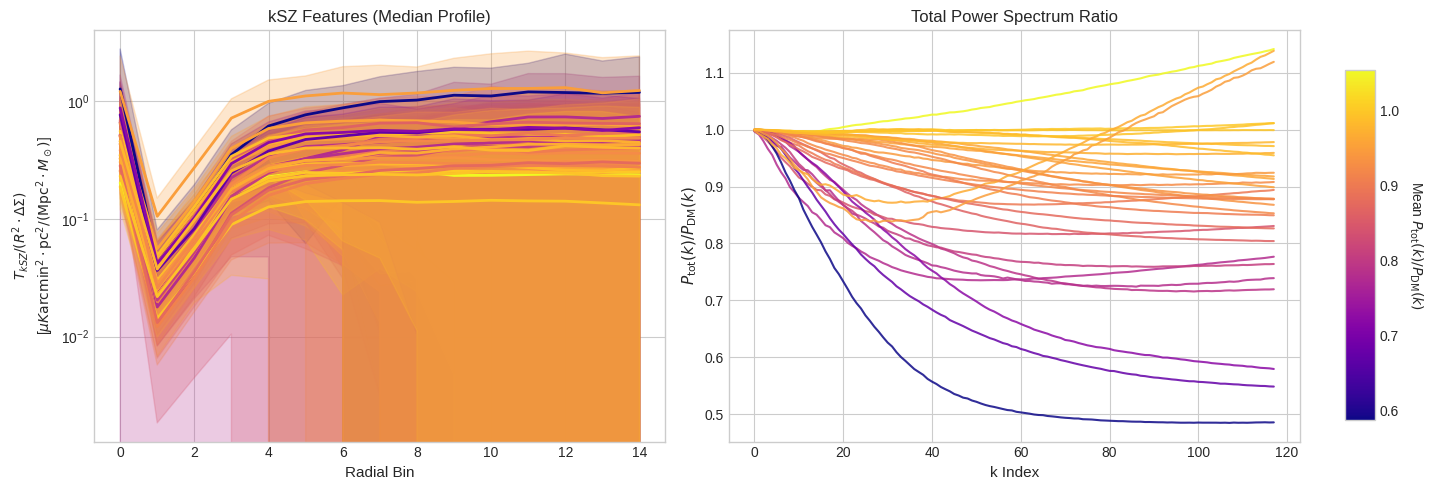

In [11]:
plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=False)

# Calculate mean Pk ratios for color mapping
n_samples = len(ptot_data)
mean_pk_ratios = [ptot_data[i].cpu().numpy().mean() for i in range(n_samples)]

# Create colormap
cmap = plt.cm.plasma
norm = plt.Normalize(vmin=min(mean_pk_ratios), vmax=max(mean_pk_ratios))

# Plot ksz_features
ax = axes[0]
# Reshape ksz_features: assuming shape is (batch, 15*900) -> (batch, 15, 900)
n_radial_bins = 15
ksz_reshaped = ksz_features.cpu().numpy().reshape(-1, n_radial_bins, 900)

# For each batch sample, compute median, min, max across the 900 samples at each radial bin
for i in range(n_samples):
    median_profile = np.median(ksz_reshaped[i], axis=1)
    min_profile = np.nanpercentile(ksz_reshaped[i], 16, axis=1)
    max_profile = np.nanpercentile(ksz_reshaped[i], 84, axis=1)

    color = cmap(norm(mean_pk_ratios[i]))
    radial_bins = np.arange(n_radial_bins)
    ax.plot(radial_bins, median_profile, linewidth=2.0, color=color)
    ax.fill_between(radial_bins, min_profile, max_profile, alpha=0.25, color=color)

ax.set_xlabel('Radial Bin', fontsize=11)
ax.set_ylabel(r'$T_{kSZ} / (R^2 \cdot \Delta \Sigma)$' + '\n' + r'[$\mu K  \mathrm{arcmin}^2 \cdot \mathrm{pc}^2 / (\mathrm{Mpc}^2 \cdot M_\odot)$]', fontsize=10)
ax.set_title('kSZ Features (Median Profile)', fontsize=12)
ax.set_yscale('log')
ax.tick_params(axis='both', which='major', labelsize=10)

# Plot ptot_data
ax = axes[1]
for i in range(n_samples):
    color = cmap(norm(mean_pk_ratios[i]))
    ax.plot(ptot_data[i].cpu().numpy(), alpha=0.85, linewidth=1.5, color=color)
ax.set_xlabel('k Index', fontsize=11)
ax.set_ylabel(r'$P_{\rm tot}(k) / P_{\rm DM}(k)$', fontsize=11)
ax.set_title('Total Power Spectrum Ratio', fontsize=12)
ax.tick_params(axis='both', which='major', labelsize=10)

# Place colorbar outside the second subplot
fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label(r'Mean $P_{\rm tot}(k) / P_{\rm DM}(k)$', rotation=270, labelpad=18)

plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.show()
